# 实验一：图像基本操作与颜色空间转换

**实验目的：** 了解图像基本信息，掌握图像的裁剪、缩放、旋转、彩色转灰度及HSV颜色空间转换等基本点运算与空间操作。
**实验准备：** 请确保在当前目录下有一张名为 `test.jpg` 的彩色图像。

## 导入依赖及辅助函数
首先，我们将导入必要的依赖库，并定义一个用于在 Matplotlib 中正确显示 OpenCV (BGR 格式) 图像的辅助函数。

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 辅助函数：用于在 Matplotlib 中正确显示 OpenCV 图像 ---
# OpenCV 默认读取格式为 BGR，而 Matplotlib 显示格式为 RGB
def cv_show(title, img, is_gray=False):
    if is_gray:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')

## 1. 任务 1：读取、显示图像及输出基本信息

In [2]:
print("--- 任务 1：图像基本信息 ---")

# 读取彩色图像
img_color = cv2.imread('test.jpg')
if img_color is None:
    print("错误：找不到 test.jpg，请检查路径！")
else:
    # 读取灰度图像 (使用 cv2.IMREAD_GRAYSCALE 标志)
    img_gray = cv2.imread('test.jpg', cv2.IMREAD_GRAYSCALE)

    print(f"彩色图像 - 尺寸(高, 宽, 通道): {img_color.shape}, 数据类型: {img_color.dtype}")
    print(f"灰度图像 - 尺寸(高, 宽): {img_gray.shape}, 数据类型: {img_gray.dtype}")

--- 任务 1：图像基本信息 ---
彩色图像 - 尺寸(高, 宽, 通道): (240, 320, 3), 数据类型: uint8
灰度图像 - 尺寸(高, 宽): (240, 320), 数据类型: uint8


## 2. 任务 2：图像的裁剪、缩放和旋转

In [3]:
# 裁剪 (利用 NumPy 切片 [y1:y2, x1:x2])
cropped_img = img_color[50:300, 50:300] 

# 缩放 (缩小为原来的一半)
scaled_img = cv2.resize(img_color, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)

# 旋转 (绕中心逆时针旋转 45 度)
(h, w) = img_color.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle=45, scale=1.0)
rotated_img = cv2.warpAffine(img_color, M, (w, h))

## 3. 任务 3：彩色图像转灰度图像 (内置函数 vs 手动实现)

In [4]:
# 3.1 使用内置函数
gray_builtin = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# 3.2 手动实现公式: Y = 0.299R + 0.587G + 0.114B
# 注意：OpenCV 读取的通道顺序是 B, G, R
b, g, r = cv2.split(img_color)
# 计算时先转换为浮点数防止溢出，算完后再转回 uint8 (0-255)
gray_manual = (0.299 * r.astype(np.float32) + 
               0.587 * g.astype(np.float32) + 
               0.114 * b.astype(np.float32)).astype(np.uint8)

## 4. 任务 4：RGB 转换为 HSV 及通道分离

In [5]:
hsv_img = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)
# 分离 H (色调), S (饱和度), V (明度) 通道
h_channel, s_channel, v_channel = cv2.split(hsv_img)

## 5. 可视化展示所有结果

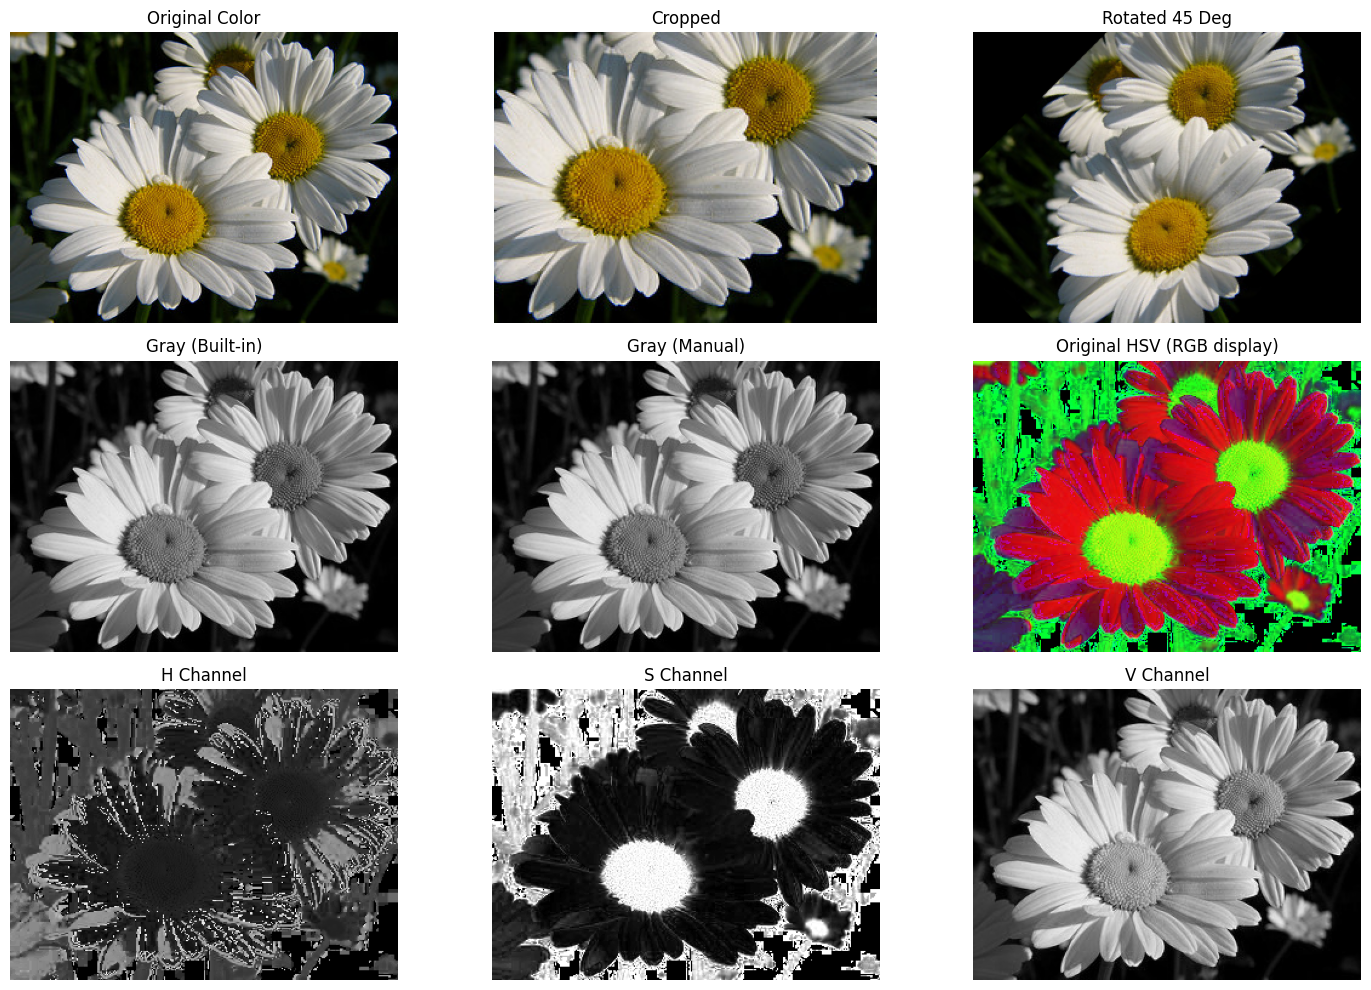

In [6]:
plt.figure(figsize=(15, 10))

plt.subplot(3, 3, 1); cv_show("Original Color", img_color)
plt.subplot(3, 3, 2); cv_show("Cropped", cropped_img)
plt.subplot(3, 3, 3); cv_show("Rotated 45 Deg", rotated_img)

plt.subplot(3, 3, 4); cv_show("Gray (Built-in)", gray_builtin, is_gray=True)
plt.subplot(3, 3, 5); cv_show("Gray (Manual)", gray_manual, is_gray=True)
plt.subplot(3, 3, 6); cv_show("Original HSV (RGB display)", hsv_img) # 直接显HSV颜色会很怪异

plt.subplot(3, 3, 7); cv_show("H Channel", h_channel, is_gray=True)
plt.subplot(3, 3, 8); cv_show("S Channel", s_channel, is_gray=True)
plt.subplot(3, 3, 9); cv_show("V Channel", v_channel, is_gray=True)

plt.tight_layout()
plt.show()